# Time series analysis

In this notebook we analyze the ECG signals presents in the provided data.
Precisely, we pre-process every TS and approximate them (or we extract some features from them). 

Before starting, install `wfdb`: an open source library of tools for reading, writing, and processing signals and annotations

In [1]:
!pip install wfdb 

## Defining utilities

In this section, we define helper functions to navigate and load the ECG time series data. The dataset follows the PhysioNet WFDB format with:
- **Header files (.hea)**: contain metadata (sampling rate, leads, duration)
- **Data files (.dat)**: contain the actual ECG signal values

### Data Organization
The ECG records are organized in a hierarchical structure:

time-series-project2025/ <br>
└── subject_id_hadm_id/ # e.g., 10000980_42546971 <br>
├── hadm_id.hea # e.g., 42546971.hea <br>
└── hadm_id.dat # e.g., 42546971.dat <br>


Each folder name combines:
- **subject_id**: unique patient identifier (8 digits)
- **hadm_id**: hospital admission identifier (8 digits)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

### 1. Directory Navigation Functions
These functions help locate the ECG data directory automatically, regardless of where the notebook is executed.


In [3]:
from pathlib import Path
import os

def find_ecg_root():
    """
    Find the ECG data directory dynamically.
    """
    
    possible_paths = [
        Path.cwd().parent.parent / "data" / "time-series-project2025",
        Path.cwd().parent.parent.parent / "data" / "time-series-project2025",
    ]
    
    for path in possible_paths:
        if path.exists():
            print(f"✓ Directory found: {path}")
            return path
    
    raise FileNotFoundError("Directory time-series-project2025 not found")

ecg_root_dir = find_ecg_root()

✓ Directory found: /home/gabriele/DAD/data/time-series-project2025


### 2. Record Discovery Functions
These functions scan the directory tree to find all available ECG records and parse their identifiers.


In [4]:
def find_ecg_records(ecg_root_dir=None):
    """Find all ECG records in the dataset directory."""
    if ecg_root_dir is None:
        ecg_root_dir = find_ecg_root()
    
    records = []
    for root, _, files in os.walk(ecg_root_dir):
        for f in files:
            if f.endswith(".hea"):
                record_name = f.replace(".hea", "")
                records.append(os.path.join(root, record_name))
    
    return records

In [5]:
def parse_ecg_filename(filename, root_path):
    """
    Parse ECG filename to extract subject_id and hadm_id.
    
    The naming convention is:
    - Folder: subject_id_hadm_id (e.g., 10000980_42546971)
    - File: hadm_id.hea (e.g., 42546971.hea)
    
    Parameters
    ----------
    filename : str
        ECG record filename (without .hea extension).
    root_path : str
        Full path to the record's directory.
    
    Returns
    -------
    tuple
        (subject_id, hadm_id) or (None, hadm_id) if parsing fails.
    """
    # Get parent directory name (should be subject_id_hadm_id)
    parent_dir = os.path.basename(root_path)
    
    # Check if parent directory contains underscore separator
    # Format: subject_id_hadm_id
    if '_' in parent_dir:
        parts = parent_dir.split('_')
        if len(parts) >= 2:
            subject_id = parts[0]
            hadm_id = parts[1]
            return subject_id, hadm_id
    
    # Alternative: check if filename itself contains underscore
    if '_' in filename:
        parts = filename.split('_')
        subject_id = parts[0]
        hadm_id = parts[1] if len(parts) > 1 else filename
        return subject_id, hadm_id
    
    # If no pattern matches, return None for subject_id
    return None, filename

### 3. Patient-Specific Functions
These functions filter ECG records by patient ID, enabling patient-level analysis as required by Task 3.


In [6]:
import pandas as pd


def find_patient_ecg_records(subject_id, ecg_root_dir=None):
    """
    Find all ECG records for a given subject_id.

    Parameters
    ----------
    subject_id : str or int
        The patient's subject_id to search for.
    ecg_root_dir : str or Path, optional
        Root directory containing ECG data. If None, will try to find it automatically.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: subject_id, hadm_id, record_id, record_path.
        Empty DataFrame if no records found.

    Examples
    --------
    >>> patient_ecgs = find_patient_ecg_records('10000980')
    >>> print(f"Found {len(patient_ecgs)} ECG records")
    """
    # Find ECG root directory if not provided
    if ecg_root_dir is None:
        try:
            ecg_root_dir = find_ecg_root()
        except FileNotFoundError as e:
            print(f"Error: {e}")
            return pd.DataFrame(
                columns=["subject_id", "hadm_id", "record_id", "record_path"]
            )

    # Convert subject_id to string for comparison
    subject_id = str(subject_id)
    patient_records = []

    # Walk through directory tree
    for root, dirs, files in os.walk(ecg_root_dir):
        for f in files:
            if f.endswith(".hea"):
                record_name = f.replace(".hea", "")

                # Parse filename to extract IDs
                file_subject_id, hadm_id = parse_ecg_filename(record_name, root)

                # Check if this record belongs to the requested patient
                if file_subject_id == subject_id:
                    record_path = os.path.join(root, record_name)

                    patient_records.append(
                        {
                            "subject_id": file_subject_id,
                            "hadm_id": hadm_id,
                            "record_id": record_name,
                            "record_path": record_path,
                        }
                    )

    return pd.DataFrame(patient_records)

In [7]:
def create_complete_ecg_index(ecg_root_dir=None):
    """
    Create a complete index of all ECG records in the database.
    
    Parameters
    ----------
    ecg_root_dir : str or Path, optional
        Root directory containing ECG data. If None, will try to find it automatically.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with all ECG records and their metadata.
    """
    # Find ECG root directory if not provided
    if ecg_root_dir is None:
        ecg_root_dir = find_ecg_root()
    
    all_records = []
    
    # Walk through directory tree
    for root, dirs, files in os.walk(ecg_root_dir):
        for f in files:
            if f.endswith('.hea'):
                record_name = f.replace('.hea', '')
                
                # Parse filename to extract IDs
                subject_id, hadm_id = parse_ecg_filename(record_name, root)
                record_path = os.path.join(root, record_name)
                
                all_records.append({
                    'subject_id': subject_id,
                    'hadm_id': hadm_id,
                    'record_id': record_name,
                    'record_path': record_path
                })
    
    return pd.DataFrame(all_records)


### 4. Data Loading Functions
This function loads the actual time series data from WFDB files and extracts a specific ECG lead.

**Available ECG Leads:**
- **Limb leads**: I, II, III, aVR, aVL, aVF
- **Precordial leads**: V1, V2, V3, V4, V5, V6

For this analysis, we focus on **Lead II** as it typically provides clear P-QRS-T complexes.


In [8]:
import wfdb

def load_patient_timeseries(record_path, lead='II'):
    """
    Load time series for a specific ECG record.
    
    Parameters
    ----------
    record_path : str
        Path to the ECG record (without extension).
    lead : str, default='II'
        ECG lead to extract (e.g., 'I', 'II', 'III', 'aVR', 'V1', etc.).
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns: timestamp, value.
    
    Raises
    ------
    ValueError
        If the specified lead is not found in the record.
    """
    import numpy as np
    
    # Read ECG record
    sig, fields = wfdb.rdsamp(record_path)
    fs = fields['fs']
    
    # Check if lead exists
    if lead not in fields['sig_name']:
        available_leads = ', '.join(fields['sig_name'])
        raise ValueError(
            f"Lead '{lead}' not found in record. "
            f"Available leads: {available_leads}"
        )
    
    # Extract lead index
    lead_idx = fields['sig_name'].index(lead)
    
    # Create time series
    n_samples = sig.shape[0]
    timestamps = np.arange(n_samples) / fs
    values = sig[:, lead_idx]
    
    return pd.DataFrame({
        'timestamp': timestamps,
        'value': values
    })

Example of usage of these functions:

In [9]:
subject_id = "10000980"

print(f"Searching for ECG records of patient {subject_id}...")
patient_ecgs = find_patient_ecg_records(subject_id=subject_id)

if len(patient_ecgs) > 0:
    print(f"\n✓ Found {len(patient_ecgs)} ECG record(s) for patient {subject_id}")
    print("\nRecord details:")
    print(patient_ecgs)

    # Load first record as example
    if len(patient_ecgs) > 0:
        print(f"\n--- Loading first record ---")
        first_record = patient_ecgs.iloc[0]
        ts = load_patient_timeseries(first_record["record_path"], lead="II")
        print(f"Time series shape: {ts.shape}")
        print(f"Duration: {ts['timestamp'].max():.2f} seconds")
        print("\nFirst few samples:")
        print(ts.head())
else:
    print(f"\n✗ No ECG records found for patient {subject_id}")

# Example 2: Create complete index
print("\n" + "=" * 60)
print("Creating complete ECG index...")
ecg_index = create_complete_ecg_index()
print(f"\nTotal records: {len(ecg_index)}")
print(f"Unique patients: {ecg_index['subject_id'].nunique()}")
print(f"Unique admissions: {ecg_index['hadm_id'].nunique()}")
print("\nFirst 10 records:")
print(ecg_index.head(10))

Searching for ECG records of patient 10000980...
✓ Directory found: /home/gabriele/DAD/data/time-series-project2025

✓ Found 1 ECG record(s) for patient 10000980

Record details:
  subject_id   hadm_id record_id  \
0   10000980  42546971  42546971   

                                         record_path  
0  /home/gabriele/DAD/data/time-series-project202...  

--- Loading first record ---
Time series shape: (5000, 2)
Duration: 10.00 seconds

First few samples:
   timestamp  value
0      0.000 -0.020
1      0.002 -0.005
2      0.004 -0.005
3      0.006 -0.010
4      0.008 -0.020

Creating complete ECG index...
✓ Directory found: /home/gabriele/DAD/data/time-series-project2025

Total records: 1786
Unique patients: 1786
Unique admissions: 1786

First 10 records:
  subject_id   hadm_id record_id  \
0   12654170  40749293  40749293   
1   12839165  42104329  42104329   
2   10332928  42050030  42050030   
3   11469226  43465495  43465495   
4   16941887  49122309  49122309   
5   19968075  

## TS Pre-processing

At this point, we can produce one time series for each patient's ECG record.

According to the project guidelines, we need to:
1. Create **univariate** time series (one lead per patient)
2. Apply normalization techniques to make signals comparable
3. Handle noise and artifacts
4. Prepare data for clustering and classification tasks

### Pre-processing Pipeline

We apply the following transformations seen during the lectures:

1. **Baseline Correction** (Offset translation)
   - Remove DC offset to center the signal around zero
   - Formula: `x'(t) = x(t) - mean(x)`

2. **Amplitude Normalization** (Amplitude scaling)
   - Standardize signal amplitude across patients
   - Methods: Min-Max scaling or Z-score normalization

3. **Detrending** (Linear Trend removal)
   - Remove long-term drift in the signal
   - Use linear or polynomial detrending

4. **Noise Filtering** (Noise removal)
   - Apply band-pass filtering to remove baseline wander and high-frequency noise
   - Typical ECG frequency range: 0.5-40 Hz
"""

Below we define the functions that apply these transformations:

In [10]:
import numpy as np
from scipy import signal
from scipy.signal import butter, filtfilt, detrend

In [11]:
def baseline_correction(ts_data):
    """
    Remove DC offset by centering the signal around zero.
    
    Parameters
    ----------
    ts_data : pd.DataFrame
        Time series with 'timestamp' and 'value' columns.
    
    Returns
    -------
    pd.DataFrame
        Corrected time series.
    """
    corrected = ts_data.copy()
    corrected['value'] = ts_data['value'] - ts_data['value'].mean()
    return corrected

In [12]:
def normalize_amplitude(ts_data, method='zscore'):
    """
    Normalize signal amplitude.
    
    Parameters
    ----------
    ts_data : pd.DataFrame
        Time series with 'timestamp' and 'value' columns.
    method : str, default='zscore'
        Normalization method: 'zscore' or 'minmax'.
    
    Returns
    -------
    pd.DataFrame
        Normalized time series.
    """
    normalized = ts_data.copy()
    
    if method == 'zscore':
        # Z-score normalization: (x - μ) / σ
        mean = ts_data['value'].mean()
        std = ts_data['value'].std()
        normalized['value'] = (ts_data['value'] - mean) / std
        
    elif method == 'minmax':
        # Min-Max scaling: (x - min) / (max - min)
        min_val = ts_data['value'].min()
        max_val = ts_data['value'].max()
        normalized['value'] = (ts_data['value'] - min_val) / (max_val - min_val)
    
    return normalized

In [13]:
def remove_linear_trend(ts_data):
    """
    Remove linear trend from the signal.
    
    Parameters
    ----------
    ts_data : pd.DataFrame
        Time series with 'timestamp' and 'value' columns.
    
    Returns
    -------
    pd.DataFrame
        Detrended time series.
    """
    detrended = ts_data.copy()
    detrended['value'] = detrend(ts_data['value'], type='linear')
    return detrended

In [14]:
def moving_average_filter(tsdata, window_size=5):
    """
    Apply moving average filter to remove noise.
    
    Parameters
    ----------
    tsdata : pd.DataFrame
        Time series with 'timestamp' and 'value' columns.
    window_size : int, default=5
        Size of the moving average window.
    
    Returns
    -------
    pd.DataFrame
        Filtered time series.
    """
    filtered = tsdata.copy()
    # Applicazione moving average con pandas rolling
    filtered['value'] = tsdata['value'].rolling(
        window=window_size, 
        center=True,
        min_periods=1  # evita NaN ai bordi
    ).mean()
    
    return filtered

### Applying pre-processing

In [15]:
def preprocess_ecg(
    tsdata,
    fs=500,
    apply_baseline=True,
    apply_normalize=True,
    apply_detrend=True,
    apply_filter=True,
    norm_method='zscore',
    window_size=5  # NEW parameter for MA
):
    """
    Complete preprocessing pipeline for ECG signals.
    
    Parameters
    ----------
    tsdata : pd.DataFrame
        Raw time series with 'timestamp' and 'value' columns.
    fs : float, default=500
        Sampling frequency (Hz).
    apply_baseline : bool, default=True
        Whether to apply baseline correction.
    apply_normalize : bool, default=True
        Whether to normalize amplitude.
    apply_detrend : bool, default=True
        Whether to remove linear trend.
    apply_filter : bool, default=True
        Whether to apply noise filtering (moving average).
    norm_method : str, default='zscore'
        Normalization method: 'zscore' or 'minmax'.
    window_size : int, default=5
        Window size for moving average filter (number of samples).
    
    Returns
    -------
    pd.DataFrame
        Preprocessed time series with same structure as input.
    
    Notes
    -----
    The preprocessing pipeline follows these steps:
    1. Baseline correction - removes DC offset
    2. Detrending - removes linear drift
    3. Noise filtering - applies moving average filter
    4. Amplitude normalization - standardizes signal amplitude (applied last)
    
    Examples
    --------
    >>> raw_ts = load_patient_timeseries(record_path, lead='II')
    >>> processed_ts = preprocess_ecg(raw_ts, fs=500, window_size=10)
    """
    processed = tsdata.copy()
    
    # 1. Baseline correction
    if apply_baseline:
        processed = baseline_correction(processed)
    
    # 2. Remove linear trend
    if apply_detrend:
        processed = remove_linear_trend(processed)
    
    # 3. Noise filtering with moving average
    if apply_filter:
        processed = moving_average_filter(processed, window_size=window_size)
    
    # 4. Amplitude normalization (applied last)
    if apply_normalize:
        processed = normalize_amplitude(processed, method=norm_method)
    
    return processed


In [16]:
# Code cell: Visualization Functions
def plot_preprocessing_comparison(raw_ts, processed_ts, title="ECG Preprocessing"):
    """
    Compare raw and preprocessed signals side by side.
    
    Parameters
    ----------
    raw_ts : pd.DataFrame
        Raw time series.
    processed_ts : pd.DataFrame
        Preprocessed time series.
    title : str
        Plot title.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Raw signal
    ax1.plot(raw_ts['timestamp'], raw_ts['value'], 'b-', linewidth=0.5)
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Amplitude (mV)')
    ax1.set_title(f'{title} - Raw Signal')
    ax1.grid(True, alpha=0.3)
    
    # Preprocessed signal
    ax2.plot(processed_ts['timestamp'], processed_ts['value'], 'r-', linewidth=0.5)
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Normalized Amplitude')
    ax2.set_title(f'{title} - Preprocessed Signal')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


Here an example of pre-processing of a patient's ECG 

✓ Directory found: /home/gabriele/DAD/data/time-series-project2025


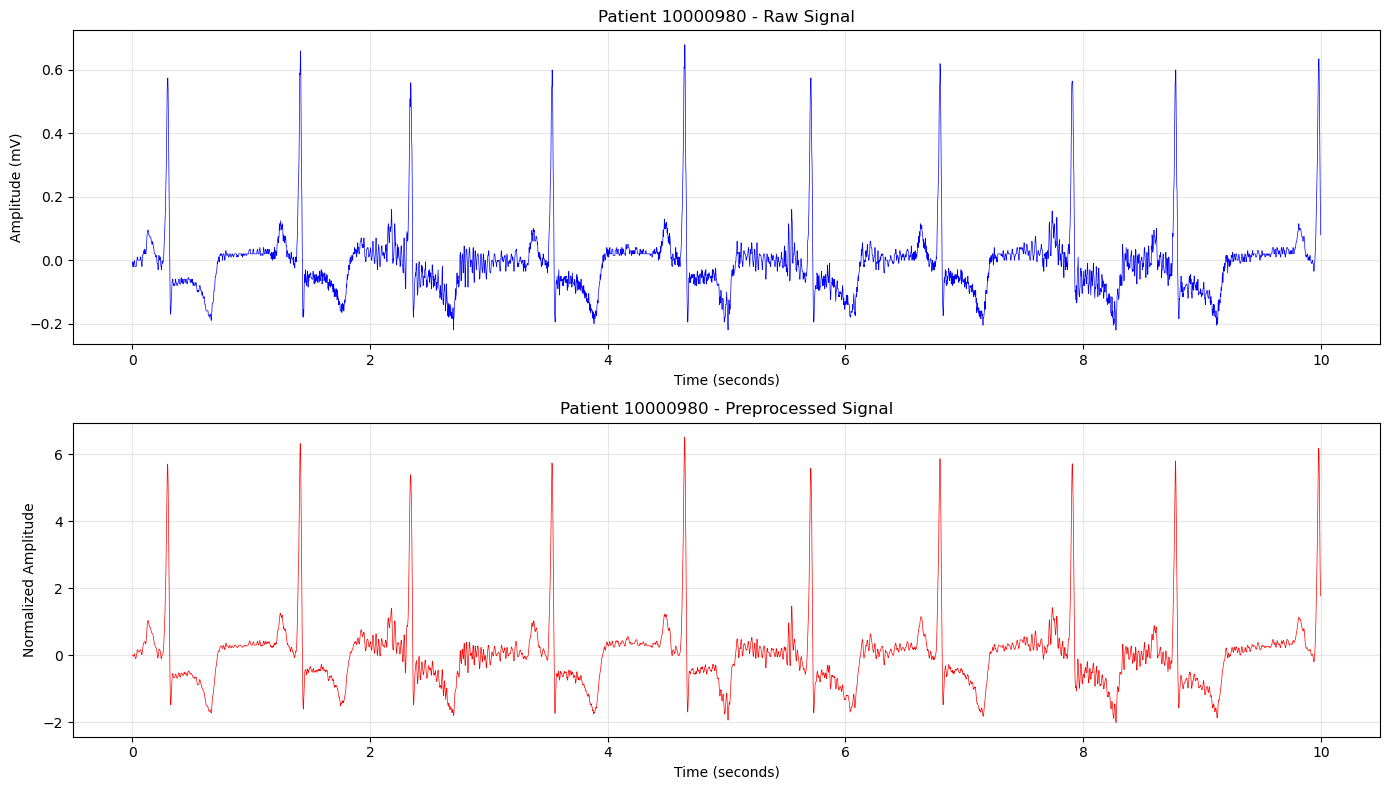

Raw Signal Statistics:
  Mean: -0.0084 mV
  Std:  0.1017 mV
  Min:  -0.2200 mV
  Max:  0.6800 mV

Processed Signal Statistics:
  Mean: 0.0000
  Std:  1.0000
  Min:  -2.0132
  Max:  6.5157


In [17]:
subject_id = "10000980"
patient_ecgs = find_patient_ecg_records(subject_id)

if len(patient_ecgs) > 0:
    first_record = patient_ecgs.iloc[0]
    
    # Load raw data
    raw_ts = load_patient_timeseries(first_record['record_path'], lead='II')
    
    # Apply preprocessing
    processed_ts = preprocess_ecg(
        raw_ts, 
        fs=500,
        apply_baseline=True,
        apply_normalize=True,
        apply_detrend=True,
        apply_filter=True,
        norm_method='zscore'
    )
    
    # Visualize comparison
    plot_preprocessing_comparison(raw_ts, processed_ts, 
                                   title=f"Patient {subject_id}")
    
    # Print statistics
    print("Raw Signal Statistics:")
    print(f"  Mean: {raw_ts['value'].mean():.4f} mV")
    print(f"  Std:  {raw_ts['value'].std():.4f} mV")
    print(f"  Min:  {raw_ts['value'].min():.4f} mV")
    print(f"  Max:  {raw_ts['value'].max():.4f} mV")
    
    print("\nProcessed Signal Statistics:")
    print(f"  Mean: {processed_ts['value'].mean():.4f}")
    print(f"  Std:  {processed_ts['value'].std():.4f}")
    print(f"  Min:  {processed_ts['value'].min():.4f}")
    print(f"  Max:  {processed_ts['value'].max():.4f}")


## Feature extraction and temporal approximation (PAA)

In [18]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from pathlib import Path

In [19]:
def extract_ecg_features(signal, fs=500):
    """
    Extract statistical and morphological features from an ECG signal.
    
    Parameters
    ----------
    signal : array-like
        Preprocessed ECG signal
    fs : int
        Sampling frequency (Hz)
        
    Returns
    -------
    dict
        Dictionary with all extracted features
    """
    features = {}
    
    # ========== STATISTICAL FEATURES ==========
    features['mean'] = np.mean(signal)
    features['std'] = np.std(signal)
    features['min'] = np.min(signal)
    features['max'] = np.max(signal)
    features['range'] = features['max'] - features['min']
    features['skewness'] = skew(signal)
    features['kurtosis'] = kurtosis(signal)
    features['energy'] = np.sum(signal**2)
    features['rms'] = np.sqrt(np.mean(signal**2))
    
    # Percentiles
    features['q25'] = np.percentile(signal, 25)
    features['q50'] = np.percentile(signal, 50)  # median
    features['q75'] = np.percentile(signal, 75)
    features['iqr'] = features['q75'] - features['q25']
    
    # ========== MORPHOLOGICAL FEATURES (Heart Rate) ==========
    try:
        # Find R-peaks (QRS complex)
        peaks, properties = find_peaks(
            signal, 
            distance=int(fs * 0.6),  # 0.6 seconds
            height=np.std(signal) * 0.5  # adaptive threshold
        )
        
        if len(peaks) > 1:
            # Calculate R-R intervals in seconds
            rr_intervals = np.diff(peaks) / fs
            
            features['mean_hr'] = 60 / np.mean(rr_intervals)
            features['std_hr'] = np.std(60 / rr_intervals) if len(rr_intervals) > 1 else 0
            features['min_hr'] = 60 / np.max(rr_intervals)
            features['max_hr'] = 60 / np.min(rr_intervals)
            features['hr_variability'] = np.std(rr_intervals)
            features['rmssd'] = np.sqrt(np.mean(np.diff(rr_intervals)**2))
            features['num_peaks'] = len(peaks)
        else:
            for key in ['mean_hr', 'std_hr', 'min_hr', 'max_hr', 'hr_variability', 'rmssd', 'num_peaks']:
                features[key] = 0
            
    except Exception as e:
        print(f"Error extracting HR features: {e}")
        for key in ['mean_hr', 'std_hr', 'min_hr', 'max_hr', 'hr_variability', 'rmssd', 'num_peaks']:
            features[key] = 0
    
    # ========== FREQUENCY DOMAIN FEATURES ==========
    try:
        # FFT
        fft_vals = np.fft.fft(signal)
        fft_mag = np.abs(fft_vals[:len(fft_vals)//2])
        fft_freq = np.fft.fftfreq(len(signal), 1/fs)[:len(fft_vals)//2]
        
        features['fft_mean'] = np.mean(fft_mag)
        features['fft_std'] = np.std(fft_mag)
        features['fft_max'] = np.max(fft_mag)
        
        # Dominant frequency
        dominant_idx = np.argmax(fft_mag)
        features['dominant_freq'] = fft_freq[dominant_idx]
        
        # Power spectral density in specific bands
        # VLF (0-0.04 Hz), LF (0.04-0.15 Hz), HF (0.15-0.4 Hz)
        vlf_mask = (fft_freq >= 0) & (fft_freq < 0.04)
        lf_mask = (fft_freq >= 0.04) & (fft_freq < 0.15)
        hf_mask = (fft_freq >= 0.15) & (fft_freq < 0.4)
        
        features['vlf_power'] = np.sum(fft_mag[vlf_mask]**2)
        features['lf_power'] = np.sum(fft_mag[lf_mask]**2)
        features['hf_power'] = np.sum(fft_mag[hf_mask]**2)
        features['lf_hf_ratio'] = features['lf_power'] / features['hf_power'] if features['hf_power'] > 0 else 0
        
    except Exception as e:
        print(f"Error extracting frequency features: {e}")
        for key in ['fft_mean', 'fft_std', 'fft_max', 'dominant_freq', 'vlf_power', 'lf_power', 'hf_power', 'lf_hf_ratio']:
            features[key] = 0
    
    return features


In [20]:
# Apply to all patients
print("="*60)
print("FEATURE EXTRACTION FROM TIME SERIES")
print("="*60)

ecg_index = create_complete_ecg_index()
print(f"\nTotal patients: {len(ecg_index)}")

features_list = []

for idx, row in ecg_index.iterrows():
    subject_id = row['subject_id']
    record_path = row['record_path']
    
    try:
        ts = load_patient_timeseries(record_path, lead='II')
        ts_processed = preprocess_ecg(ts, fs=500)
        features = extract_ecg_features(ts_processed['value'].values, fs=500)
        features['subject_id'] = subject_id
        features['hadm_id'] = row['hadm_id']
        features_list.append(features)
        
        if (idx + 1) % 100 == 0:
            print(f"Processed {idx + 1}/{len(ecg_index)} patients...")
            
    except Exception as e:
        print(f"Error for patient {subject_id}: {e}")
        continue

df_features = pd.DataFrame(features_list)

print(f"\n✓ Features extracted for {len(df_features)} patients")
print(f"✓ Number of features: {len(df_features.columns) - 2}")
print(f"\nFirst rows:")
print(df_features.head())

FEATURE EXTRACTION FROM TIME SERIES
✓ Directory found: /home/gabriele/DAD/data/time-series-project2025

Total patients: 1786
Processed 100/1786 patients...
Processed 200/1786 patients...
Processed 300/1786 patients...
Processed 400/1786 patients...
Processed 500/1786 patients...
Processed 600/1786 patients...
Processed 700/1786 patients...
Processed 800/1786 patients...
Processed 900/1786 patients...
Processed 1000/1786 patients...
Processed 1100/1786 patients...
Processed 1200/1786 patients...
Processed 1300/1786 patients...
Processed 1400/1786 patients...
Processed 1500/1786 patients...
Processed 1600/1786 patients...
Processed 1700/1786 patients...

✓ Features extracted for 1786 patients
✓ Number of features: 28

First rows:
           mean     std       min       max     range  skewness   kurtosis  \
0  1.136868e-17  0.9999 -4.327704  1.855187  6.182891 -1.057921   1.187727   
1  1.563194e-17  0.9999 -0.687829  7.379365  8.067194  5.118452  27.640425   
2  0.000000e+00  0.9999 -3.4

In [21]:
## 2. Temporal Approximation (PAA)

def piecewise_aggregate_approximation(signal, n_segments=100):
    """
    Reduce a time series to n_segments through segment-wise averaging.
    
    Parameters
    ----------
    signal : array-like
        Signal to approximate
    n_segments : int
        Number of segments to divide the signal into
        
    Returns
    -------
    np.ndarray
        Array with PAA values
    """
    signal = np.array(signal)
    segment_len = len(signal) // n_segments
    paa = []
    
    for i in range(n_segments):
        start = i * segment_len
        end = start + segment_len
        
        if i == n_segments - 1:
            end = len(signal)
            
        paa.append(np.mean(signal[start:end]))
    
    return np.array(paa)

In [22]:
print("\n" + "="*60)
print("TEMPORAL APPROXIMATION WITH PAA")
print("="*60)

N_SEGMENTS = 100
paa_list = []

for idx, row in ecg_index.iterrows():
    subject_id = row['subject_id']
    record_path = row['record_path']
    
    try:
        ts = load_patient_timeseries(record_path, lead='II')
        ts_processed = preprocess_ecg(ts, fs=500)
        paa_values = piecewise_aggregate_approximation(
            ts_processed['value'].values, 
            n_segments=N_SEGMENTS
        )
        
        paa_dict = {'subject_id': subject_id, 'hadm_id': row['hadm_id']}
        for i, val in enumerate(paa_values):
            paa_dict[f'paa_{i}'] = val
        
        paa_list.append(paa_dict)
        
        if (idx + 1) % 100 == 0:
            print(f"Processed {idx + 1}/{len(ecg_index)} patients...")
            
    except Exception as e:
        print(f"Error for patient {subject_id}: {e}")
        continue

df_paa = pd.DataFrame(paa_list)

print(f"\n✓ PAA calculated for {len(df_paa)} patients")
print(f"✓ Number of PAA segments: {N_SEGMENTS}")
print(f"\nShape: {df_paa.shape}")


TEMPORAL APPROXIMATION WITH PAA
Processed 100/1786 patients...
Processed 200/1786 patients...
Processed 300/1786 patients...
Processed 400/1786 patients...
Processed 500/1786 patients...
Processed 600/1786 patients...
Processed 700/1786 patients...
Processed 800/1786 patients...
Processed 900/1786 patients...
Processed 1000/1786 patients...
Processed 1100/1786 patients...
Processed 1200/1786 patients...
Processed 1300/1786 patients...
Processed 1400/1786 patients...
Processed 1500/1786 patients...
Processed 1600/1786 patients...
Processed 1700/1786 patients...

✓ PAA calculated for 1786 patients
✓ Number of PAA segments: 100

Shape: (1786, 102)


In [23]:
## 3. Saving DataFrames

print("\n" + "="*60)
print("SAVING DATAFRAMES")
print("="*60)

output_dir = Path("data")
output_dir.mkdir(parents=True, exist_ok=True)

# Save features
df_features.to_csv(output_dir / "ecg_features.csv", index=False)
df_features.to_pickle(output_dir / "ecg_features.pkl")
print(f"\n✓ Features saved to: {output_dir / 'ecg_features.csv'}")

# Save PAA
df_paa.to_csv(output_dir / "ecg_paa.csv", index=False)
df_paa.to_pickle(output_dir / "ecg_paa.pkl")
print(f"✓ PAA saved to: {output_dir / 'ecg_paa.csv'}")

# Summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"\n EXTRACTED FEATURES:")
print(f"   - Patients: {len(df_features)}")
print(f"   - Features per patient: {len(df_features.columns) - 2}")

print(f"\n PAA APPROXIMATION:")
print(f"   - Patients: {len(df_paa)}")
print(f"   - PAA segments: {N_SEGMENTS}")

print("\n All data has been saved successfully!")


SAVING DATAFRAMES

✓ Features saved to: data/ecg_features.csv
✓ PAA saved to: data/ecg_paa.csv

SUMMARY

 EXTRACTED FEATURES:
   - Patients: 1786
   - Features per patient: 28

 PAA APPROXIMATION:
   - Patients: 1786
   - PAA segments: 100

 All data has been saved successfully!



📌 Example visualization for patient: 10577266


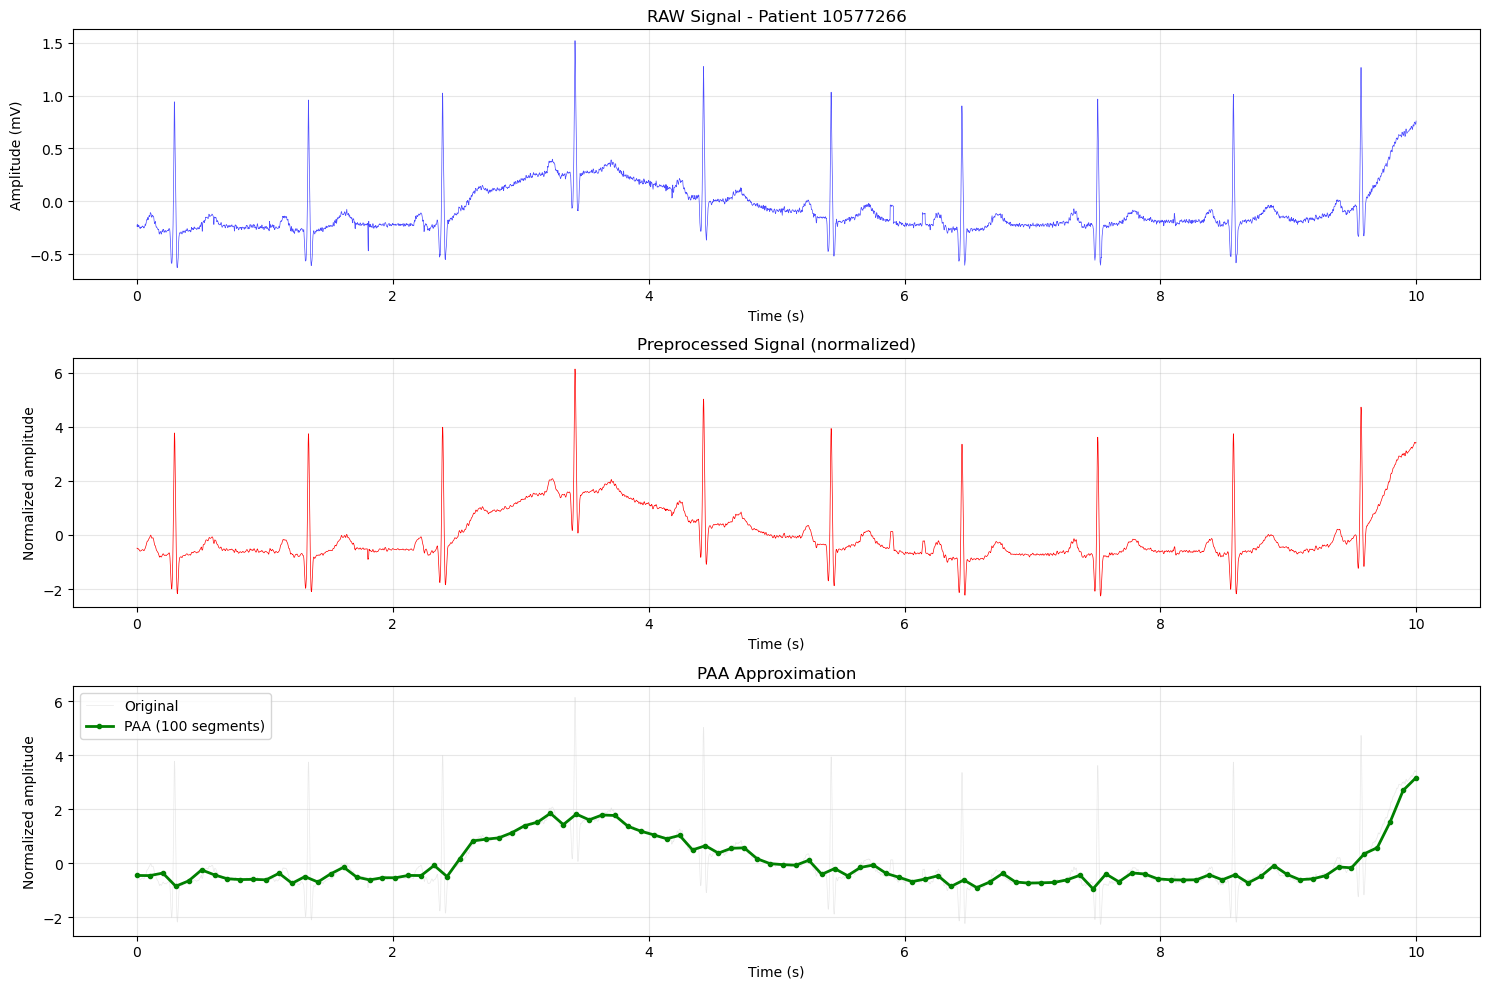


✓ Visualization saved to: data/example_paa_visualization.png


In [24]:
import matplotlib.pyplot as plt

random_idx = np.random.randint(0, len(ecg_index))
patient_record = ecg_index.iloc[random_idx]

print(f"\n📌 Example visualization for patient: {patient_record['subject_id']}")

ts_raw = load_patient_timeseries(patient_record['record_path'], lead='II')
ts_processed = preprocess_ecg(ts_raw, fs=500)
paa_values = piecewise_aggregate_approximation(ts_processed['value'].values, n_segments=N_SEGMENTS)

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Raw signal
axes[0].plot(ts_raw['timestamp'], ts_raw['value'], 'b-', linewidth=0.5, alpha=0.7)
axes[0].set_title(f'RAW Signal - Patient {patient_record["subject_id"]}')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, alpha=0.3)

# Preprocessed signal
axes[1].plot(ts_processed['timestamp'], ts_processed['value'], 'r-', linewidth=0.5)
axes[1].set_title('Preprocessed Signal (normalized)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Normalized amplitude')
axes[1].grid(True, alpha=0.3)

# PAA approximation
paa_timestamps = np.linspace(0, ts_processed['timestamp'].max(), N_SEGMENTS)
axes[2].plot(ts_processed['timestamp'], ts_processed['value'], 'lightgray', 
             linewidth=0.5, alpha=0.5, label='Original')
axes[2].plot(paa_timestamps, paa_values, 'g-', linewidth=2, marker='o', 
             markersize=3, label=f'PAA ({N_SEGMENTS} segments)')
axes[2].set_title('PAA Approximation')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Normalized amplitude')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'example_paa_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: {output_dir / 'example_paa_visualization.png'}")